# Day 3 — Backpropagation, Gradient Descent & Optimizers

## Overview

This notebook explores the fundamental training process of a neural network.

The main concepts covered are:

- The four-step neural network training loop
- Gradient descent
- Learning rate
- Backpropagation
- Chain rule
- Optimizers
- Epochs and batches
- Comparing different learning rates

The experiments are performed using the cleaned cardiovascular disease dataset (cardio_cleaned).

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



## 2. Load the Dataset

The dataset used in this experiment is the cleaned cardiovascular disease dataset from the previous work.

The target variable is cardio, which indicates whether cardiovascular disease is present:

- 0 → No cardiovascular disease
- 1 → Cardiovascular disease

In [4]:
df = pd.read_csv("/content/cardio_cleaned.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (68742, 13)


,id,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,2,168,62.0,110,80,1,1,0,0,1,0,50.357290
1,1,1,156,85.0,140,90,3,1,0,0,1,1,55.381246
2,2,1,165,64.0,130,70,3,1,0,0,0,1,51.627652
3,3,2,169,82.0,150,100,1,1,0,0,1,1,48.249144
4,4,1,156,56.0,100,60,1,1,0,0,0,0,47.841205


In [6]:
print("Columns:",df.columns.tolist())
print("Missing values:",df.isnull().sum())

print("Duplicate rows:",df.duplicated().sum())
print("Target distribution:",df["cardio"].value_counts())


Columns: ['id', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years']
Missing values: id             0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64
Duplicate rows: 0
Target distribution: cardio
0    34720
1    34022
Name: count, dtype: int64


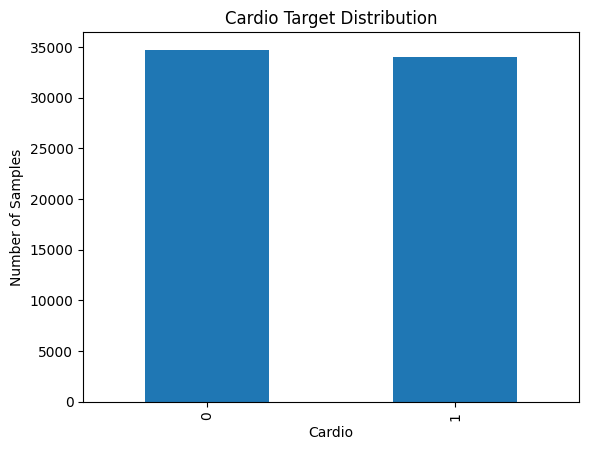

In [7]:
df["cardio"].value_counts().plot(
    kind="bar",
    title="Cardio Target Distribution"
)

plt.xlabel("Cardio")
plt.ylabel("Number of Samples")
plt.show()

In [9]:
X = df.drop(["cardio", "id"], axis=1)
y = df["cardio"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (68742, 11)
Target shape: (68742,)


## 5. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% is used for testing.
- stratify=y preserves the target class distribution in both sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 54993
Testing samples: 13749


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (54993, 11)
Testing data shape: (13749, 11)


##  The Four-Step Neural Network Training Loop

Training a neural network is an iterative process consisting of four main steps:

### 1. Forward Pass

The input data moves forward through the network to produce predictions.

### 2. Loss Calculation

The loss function measures the difference between the predicted values and the true labels.

### 3. Backpropagation

The gradients of the loss with respect to the model weights are calculated.

### 4. Weight Update

The optimizer uses the gradients to update the weights in a direction that reduces the loss.

The four steps are repeated for multiple batches and epochs until the model learns useful parameters.

**Training Loop:**

Forward Pass → Loss → Backpropagation → Weight Update

In [12]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_scaled.shape[1],)),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(8, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    return model

## 9. Baseline Model

The baseline model uses the Adam optimizer with a learning rate of 0.001.

Adam is a commonly used optimizer because it adapts the updates of the model parameters during training.

A learning rate of 0.001 is a common starting point for Adam.

In [13]:
baseline_model = build_model()

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 337 (1.32 KB)

 Trainable params: 337 (1.32 KB)

 Non-trainable params: 0 (0.00 B)

##  Training the Baseline Model

The model is trained for 20 epochs with a batch size of 32.

- **Epoch:** One complete pass through the training dataset.
- **Batch:** A subset of training samples processed before a weight update.

In [14]:
baseline_history = baseline_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7141 - loss: 0.5685 - val_accuracy: 0.7291 - val_loss: 0.5524
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7292 - loss: 0.5506 - val_accuracy: 0.7329 - val_loss: 0.5474
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7314 - loss: 0.5479 - val_accuracy: 0.7331 - val_loss: 0.5457
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7315 - loss: 0.5461 - val_accuracy: 0.7343 - val_loss: 0.5450
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7323 - loss: 0.5449 - val_accuracy: 0.7322 - val_loss: 0.5443
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7326 - loss: 0.5441 - val_accuracy: 0.7352 - val_loss: 0.5433
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7326 - loss: 0.5436 - val_accuracy: 0.7353 - val_loss: 0.5436
Epoch 8/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7337 - loss: 0.5431 -

##  Baseline Loss Curve

The loss curve shows how the training and validation loss change during training.

A decreasing training loss indicates that the model is learning to reduce its prediction error.

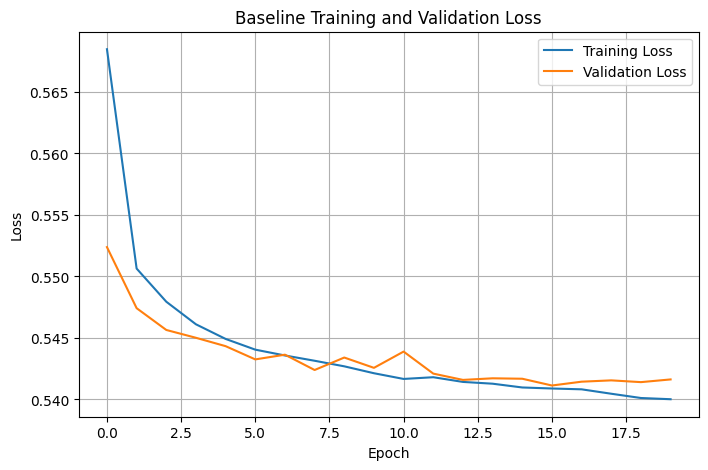

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    baseline_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

##  Gradient Descent

Gradient descent is an optimization method used to minimize the loss function.

The gradient indicates the direction of the steepest increase in the loss.

Gradient descent moves the model parameters in the opposite direction of the gradient.

The basic update rule is:

**New Weight = Old Weight − Learning Rate × Gradient**

The learning rate determines how large each update step is.

A large learning rate produces larger updates, while a small learning rate produces smaller updates.

## Learning Rate

The learning rate controls the step size used when updating the model weights.

Different learning rates can produce very different training behaviors:

| Learning Rate | Expected Behavior |
|---|---|
| Too High | May overshoot the minimum and cause unstable training |
| Good | Usually produces steady loss reduction |
| Too Low | Training may become very slow |

The experiment below compares three learning rates:

- 0.1 → High
- 0.001 → Good starting point
- 0.00001 → Very low

In [16]:
learning_rates = {
    "Too High": 0.1,
    "Good": 0.001,
    "Too Low": 0.00001
}

histories = {}

In [17]:
for name, lr in learning_rates.items():

    print(f"Training: {name} | Learning Rate = {lr}")

    model = build_model()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    histories[name] = history

print("Training completed.")

Training: Too High | Learning Rate = 0.1
Training: Good | Learning Rate = 0.001
Training: Too Low | Learning Rate = 1e-05
Training completed.


##  Comparing Training Loss

The following plot compares the training loss for the three learning rates.

The goal is to observe:

- How quickly the loss decreases.
- Whether the loss decreases smoothly.
- Whether the learning rate is too slow or unstable.

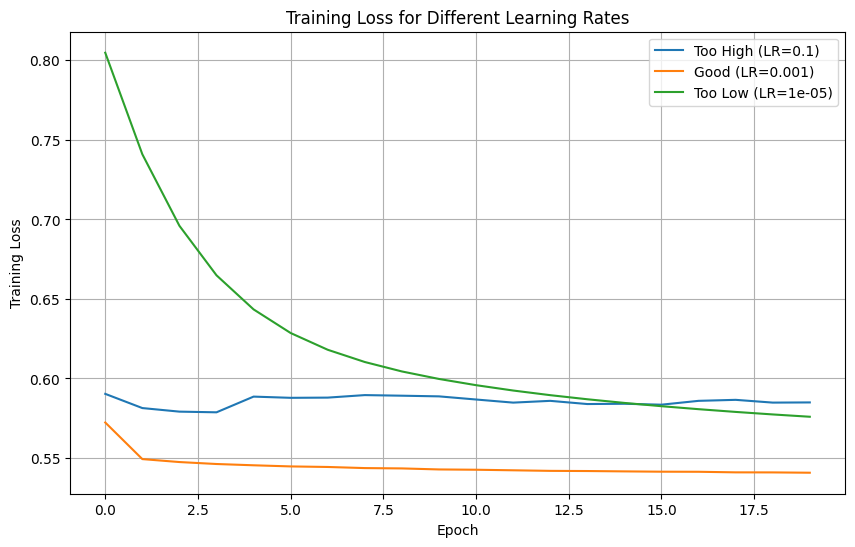

In [18]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        label=f"{name} (LR={learning_rates[name]})"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

##  Comparing Validation Loss

Validation loss helps us observe how the model performs on data that was not directly used to update the weights.

Comparing validation loss can help identify whether a learning rate leads to stable learning and good generalization.

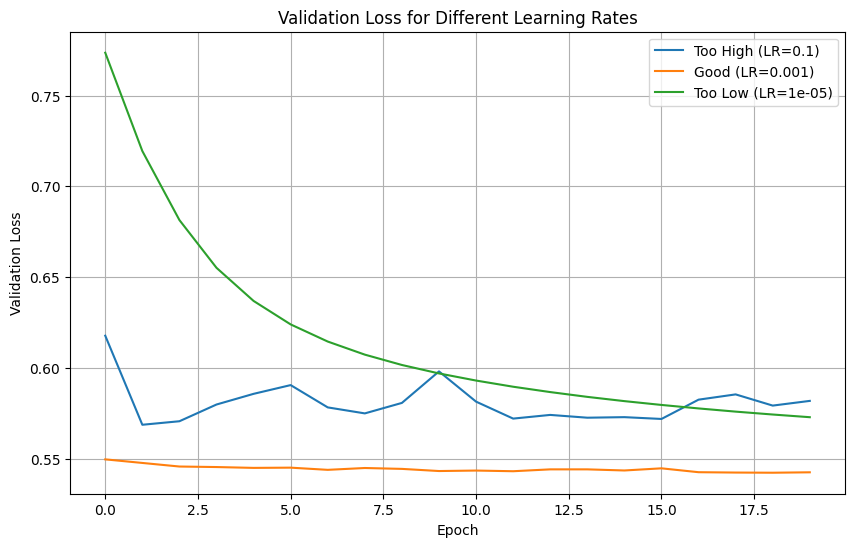

In [19]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        history.history["val_loss"],
        label=f"{name} (LR={learning_rates[name]})"
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

##  Final Loss Comparison

The final training and validation losses are summarized below to make the comparison between learning rates easier.

In [20]:
results = []

for name, history in histories.items():

    results.append({
        "Learning Rate Type": name,
        "Learning Rate": learning_rates[name],
        "Final Training Loss": history.history["loss"][-1],
        "Final Validation Loss": history.history["val_loss"][-1]
    })

results_df = pd.DataFrame(results)

results_df

,Learning Rate Type,Learning Rate,Final Training Loss,Final Validation Loss
0,Too High,0.10000,0.584927,0.581878
1,Good,0.00100,0.540733,0.542555
2,Too Low,0.00001,0.575919,0.572895


##  Backpropagation

Backpropagation is the algorithm used to calculate the gradients needed to update the neural network's weights.

After the forward pass produces a prediction, the loss function measures the prediction error.

Backpropagation then works backward through the network and calculates how much each weight contributed to the loss.

This allows the optimizer to know how the weights should be changed to reduce the error.

In simple terms, backpropagation can be thought of as **assigning responsibility for the error to the different weights**.

TensorFlow calculates these gradients automatically during model training.

##  The Chain Rule

The chain rule is important because a neural network contains many connected operations.

For example:

Input → Hidden Layer → Hidden Layer → Output → Loss

The loss depends on the output, the output depends on the previous layer, and that layer depends on earlier weights.

The chain rule allows us to calculate how a change in an earlier weight affects the final loss.

Backpropagation uses the chain rule to efficiently calculate these gradients throughout the network.


##  Optimizers

An optimizer uses the calculated gradients to update the model's weights.

### SGD

Stochastic Gradient Descent is a basic optimization algorithm that updates weights using the gradient and learning rate.

### Adam

Adam is a more advanced optimizer that adapts the update step for each parameter.

Adam is commonly used as a strong default optimizer for neural networks.

In this experiment, Adam is used for the learning-rate comparison.



##  Epochs and Batches

### Epoch

An epoch represents one complete pass through the entire training dataset.

### Batch

A batch is a subset of training samples processed before the model updates its weights.

In this experiment:

- Epochs = 20
- Batch size = 32

Therefore, the model processes the training data in batches of 32 samples and repeats the complete training process for 20 epochs.


##  Final Model

Based on the learning-rate experiment, `0.001` is used as the starting learning rate for the final model.

The model is trained again using the selected configuration and evaluated on the unseen test set.

In [21]:
final_model = build_model()

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7121 - loss: 0.5709 - val_accuracy: 0.7324 - val_loss: 0.5506
Epoch 2/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7278 - loss: 0.5514 - val_accuracy: 0.7313 - val_loss: 0.5481
Epoch 3/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7276 - loss: 0.5484 - val_accuracy: 0.7301 - val_loss: 0.5476
Epoch 4/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7305 - loss: 0.5464 - val_accuracy: 0.7326 - val_loss: 0.5448
Epoch 5/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7301 - loss: 0.5452 - val_accuracy: 0.7319 - val_loss: 0.5453
Epoch 6/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7303 - loss: 0.5444 - val_accuracy: 0.7343 - val_loss: 0.5431
Epoch 7/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7319 - loss: 0.5439 - val_accuracy: 0.7344 - val_loss: 0.5433
Epoch 8/20
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7307 - loss: 0.5434 - 

##  Model Evaluation

The final model is evaluated on the test set to measure its performance on unseen data.

In [22]:
test_loss, test_accuracy = final_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.5470505356788635
Test Accuracy: 0.7313259243965149


##  Classification Metrics

Additional classification metrics are calculated to provide a more complete evaluation.

The metrics include:

- Accuracy
- Precision
- Recall
- F1 Score

In [23]:
y_prob = final_model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = (y_prob >= 0.5).astype(int).ravel()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.7313
Precision: 0.7481
Recall   : 0.6892
F1 Score : 0.7175


##  Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for each class.

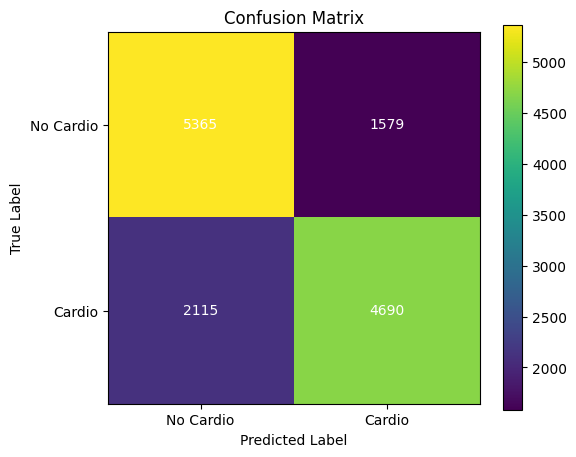

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

plt.imshow(cm, cmap="viridis")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.colorbar()

plt.xticks(
    [0, 1],
    ["No Cardio", "Cardio"]
)

plt.yticks(
    [0, 1],
    ["No Cardio", "Cardio"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white"
        )

plt.show()

## Conclusion

This notebook explored the fundamental training process of a neural network using the cleaned cardiovascular disease dataset.

The training loop consists of four main steps:

**Forward Pass → Loss → Backpropagation → Weight Update**

Gradient descent reduces the loss by updating the model's weights in the opposite direction of the calculated gradients.

The learning rate controls the size of these updates. A very high learning rate can make training unstable, while a very low learning rate can make training slow.

Three learning rates were compared:

- 0.1
- 0.001
- 0.00001

The loss curves were used to observe how the learning rate affects the training process.

Backpropagation calculates the gradients of the loss with respect to the model's weights. It uses the chain rule to propagate the effect of the error backward through the network.

The Adam optimizer was used because it provides adaptive parameter updates and is a commonly used optimizer for neural networks.

Overall, the experiment demonstrates how the optimizer, learning rate, epochs, and batches work together during neural network training.